In [1]:
import cv2
import json
import time
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image
from transformers import Qwen2TokenizerFast, Qwen3ForCausalLM, AutoConfig

from diffusers.utils import load_image
from diffusers.schedulers import FlowMatchEulerDiscreteScheduler
from diffusers.models import AutoencoderKLFlux2, Flux2Transformer2DModel

from ctgmworkshop.flux_tools import *
from ctgmworkshop.image_tools import *
from ctgmworkshop.optical_flow_tools import *

device = "cuda"
dtype = torch.bfloat16
plt.style.use("dark_background")

In [2]:
dtype = torch.bfloat16

text_encoder = Qwen3ForCausalLM.from_pretrained(
    "../../FLUX.2-klein-4B/text_encoder", local_files_only=True
).to(device, dtype)
tokenizer = Qwen2TokenizerFast.from_pretrained(
    "../../FLUX.2-klein-4B/tokenizer", local_files_only=True, device=device
)

scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained(
    "../../FLUX.2-klein-4B/scheduler", device=device
)
vae = AutoencoderKLFlux2.from_pretrained("../../FLUX.2-klein-4B/vae", device=device).to(
    device, dtype
)
transformer = Flux2Transformer2DModel.from_pretrained(
    "../../FLUX.2-klein-4B/transformer", device=device
).to(device, dtype)

vae_mean, vae_std = get_latents_mean_std(vae)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [3]:
text_encoder = torch.compile(text_encoder)
vae = torch.compile(vae)
transformer = torch.compile(transformer)

In [4]:
raft_model, raft_preprocess = get_large_raft()

In [20]:
with open("../../precomputes/flow_refractor/prompts.json") as f:
    prompts = json.load(f)


def build_random_prompt():
    r = random.randint(0, 7)
    if r < 3:
        prompt = "Turn this image into style of "
        prompt += random.choice(prompts["general_styles"])
        prompt += "."
    if r == 3:
        prompt = "Turn this image into artwork in style of "
        prompt += random.choice(prompts["artist_names"])
        prompt += ", "
        num_modifiers = random.randint(1, 3)
        for i in range(num_modifiers):
            prompt += random.choice(prompts["artwork_styles"]) + ", "
        prompt = prompt[:-2] + "."
    if r > 3:
        prompt = random.choice(prompts["instruct_prompts"])

    return prompt

In [21]:
from pathlib import Path

files = [f.name for f in Path("../../local_samples/videos").iterdir() if f.is_file()]


def random_video_path():
    path = "../../local_samples/videos/"
    path += random.choice(files)

    return path

In [22]:
random_video_path()

'../../local_samples/videos/7.mp4'

In [99]:
cap = cv2.VideoCapture(random_video_path())

In [103]:
def get_next_frame_pair(cap, skip: int = 20, distance: int = 20):

    for _ in range(skip):
        ret, frame = cap.read()
        if not ret:
            raise StopIteration("End of sequence")

    frame_A = frame

    for _ in range(distance):
        ret, frame = cap.read()
        if not ret:
            raise StopIteration("End of sequence")
    frame_B = frame

    return frame_A, frame_B


In [104]:
height = 512
width = 960

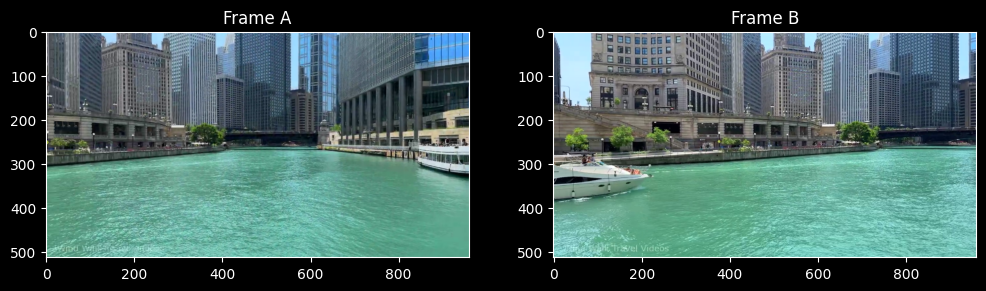

In [105]:
frame_A, frame_B = get_next_frame_pair(cap, skip=2, distance=100)


frame_A = resize_np(cv2_to_np(frame_A), height=height, width=width)
frame_B = resize_np(cv2_to_np(frame_B), height=height, width=width)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Frame A")
plt.imshow(frame_A)
plt.subplot(1, 2, 2)
plt.title("Frame B")
plt.imshow(frame_B)
plt.show()

In [106]:
# cap.release()

In [107]:
@torch.no_grad()
def prepare_reference_latents(
    reference_latents: list[torch.Tensor],
    vae,
    batch_size,
    device,
    dtype,
):
    image_latents = []
    for l in reference_latents:
        image_latent = patchify_latents(l)
        image_latents.append(image_latent)

    image_latent_ids = prepare_image_ids(image_latents)

    packed_latents = []
    for latent in image_latents:
        packed = pack_latents(latent)  # (1, seq, C)
        packed = packed.squeeze(0)  # (seq, C)
        packed_latents.append(packed)

    image_latents = torch.cat(packed_latents, dim=0)  # (N*seq, C)
    image_latents = image_latents.unsqueeze(0)  # (1, N*seq, C)

    image_latents = image_latents.repeat(batch_size, 1, 1)
    image_latent_ids = image_latent_ids.repeat(batch_size, 1, 1)
    image_latent_ids = image_latent_ids.to(device)

    return image_latents, image_latent_ids


@torch.no_grad()
def inpaint(cond, warped, prompt):
    full_prompt = "Remove gray mask and borders."

    prompt_embeds, text_ids = encode_prompt(
        prompt=full_prompt,
        text_encoder=text_encoder,
        tokenizer=tokenizer,
        device=device,
        num_images_per_prompt=1,
        max_sequence_length=512,
        text_encoder_out_layers=(9, 18, 27),
    )

    generator = torch.Generator(device="cuda")

    latents, latent_ids = prepare_latents(
        batch_size=1,
        num_latents_channels=32,
        height=height,
        width=width,
        dtype=dtype,
        device=device,
        generator=generator,
    )

    image_latents, image_latent_ids = prepare_reference_latents(
        reference_latents=[warped],
        vae=vae,
        batch_size=1,
        device=device,
        dtype=dtype,
    )
    image_latents = image_latents.to(transformer.dtype)

    num_inference_steps = 2
    sigmas = np.linspace(1.0, 1 / num_inference_steps, num_inference_steps)
    image_seq_len = latents.shape[1]
    mu = compute_empirical_mu(
        image_seq_len=image_seq_len, num_steps=num_inference_steps
    )

    timesteps, num_inference_steps = retrieve_timesteps(
        scheduler,
        num_inference_steps,
        device,
        sigmas=sigmas,
        mu=mu,
    )

    for i, t in enumerate(timesteps):
        timestep = t.expand(latents.shape[0]).to(latents.dtype)

        noise_pred = transformer(
            hidden_states=torch.cat(
                [latents.to(transformer.dtype), image_latents], dim=1
            ),
            timestep=timestep / 1000,
            guidance=None,
            encoder_hidden_states=prompt_embeds,
            txt_ids=text_ids,
            img_ids=torch.cat([latent_ids, image_latent_ids], dim=1),
            return_dict=False,
        )[0]

        noise_pred = noise_pred[:, : latents.size(1), :]
        latents = scheduler.step(noise_pred, t, latents, return_dict=False)[0]

    latents = unpack_latents_with_ids(latents, latent_ids)
    latents = unpatchify_latents(latents)

    return latents


@torch.no_grad()
def process_frame(frame, seed, prompt):
    num_inference_steps = 3

    frame = norm_image(resize_torch(cv2_to_torch(frame), height=height, width=width))

    image_latents, image_latent_ids = prepare_image_latents(
        images=[frame], vae=vae, batch_size=1, device=device, dtype=dtype
    )

    cond_latents = unpack_latents_with_ids(image_latents, image_latent_ids)
    cond_latents = unpatchify_latents(cond_latents)

    # cond_latents -> return

    prompt_embeds, text_ids = encode_prompt(
        prompt=prompt,
        text_encoder=text_encoder,
        tokenizer=tokenizer,
        device=device,
        num_images_per_prompt=1,
        max_sequence_length=512,
        text_encoder_out_layers=(9, 18, 27),
    )

    generator = torch.Generator(device="cuda").manual_seed(seed)

    latents, latent_ids = prepare_latents(
        batch_size=1,
        num_latents_channels=32,
        height=height,
        width=width,
        dtype=dtype,
        device=device,
        generator=generator,
    )

    sigmas = np.linspace(1.0, 1 / num_inference_steps, num_inference_steps)

    image_seq_len = latents.shape[1]

    mu = compute_empirical_mu(
        image_seq_len=image_seq_len, num_steps=num_inference_steps
    )

    timesteps, num_inference_steps = retrieve_timesteps(
        scheduler,
        num_inference_steps,
        device,
        sigmas=sigmas,
        mu=mu,
    )

    scheduler.set_begin_index(0)

    init_latents = latents.clone()
    init_latents = unpack_latents_with_ids(init_latents, latent_ids)
    init_latents = unpatchify_latents(init_latents)

    # init_latents -> return

    for i, t in enumerate(timesteps):
        timestep = t.expand(latents.shape[0]).to(latents.dtype)

        latent_model_input = latents.to(transformer.dtype)
        latent_image_ids = latent_ids

        noise_pred = transformer(
            hidden_states=torch.cat(
                [latent_model_input, image_latents], dim=1
            ),  # (B, image_seq_len, C)
            timestep=timestep / 1000,
            guidance=None,
            encoder_hidden_states=prompt_embeds,
            txt_ids=text_ids,  # B, text_seq_len, 4
            img_ids=torch.cat(
                [latent_image_ids, image_latent_ids], dim=1
            ),  # B, image_seq_len, 4
            return_dict=False,
        )[0]

        noise_pred = noise_pred[:, : latents.size(1), :]

        # compute the previous noisy sample x_t -> x_t-1
        latents = scheduler.step(noise_pred, t, latents, return_dict=False)[0]

    vae_scale_factor = 8

    latent_height = 2 * (int(height) // (vae_scale_factor * 2))
    latent_width = 2 * (int(width) // (vae_scale_factor * 2))

    latents = unpack_latents_with_ids(
        latents, latent_ids, latent_height // 2, latent_width // 2
    )

    final_latents = unpatchify_latents(latents)

    # final_latents -> return

    return cond_latents, init_latents, final_latents


@torch.no_grad()
def process_pair(frame_A, frame_B):

    seed = random.randint(0, 1000000)
    prompt = build_random_prompt()

    cond_latents_B, init_latents_B, final_latents_B = process_frame(
        frame_B, seed, prompt
    )

    resized_A = resize_cv2(frame_A, height=height, width=width)
    resized_B = resize_cv2(frame_B, height=height, width=width)

    image_A = cv2_to_torch(resized_A)
    image_A = norm_image(image_A)
    cond_latents_A = vae.encode(image_A.to(dtype)).latent_dist.sample()
    cond_latents_A = norm_unpatchified_latents(
        cond_latents_A, mean=vae_mean, std=vae_std
    )

    optical_flow_BA = flow_from_numpy(
        cv2_to_np(resized_B),
        cv2_to_np(resized_A),
        model=raft_model,
        preprocess=raft_preprocess,
    )

    optical_flow_AB = flow_from_numpy(
        cv2_to_np(resized_A),
        cv2_to_np(resized_B),
        model=raft_model,
        preprocess=raft_preprocess,
    )

    mask_BA = bidir_flow_mask(optical_flow_BA, optical_flow_AB, threshold=10)
    mask_AB = bidir_flow_mask(optical_flow_AB, optical_flow_BA, threshold=10)

    processed_B = denorm_unpatchified_latents(
        final_latents_B, mean=vae_mean, std=vae_std
    )
    processed_B = decode_latents(processed_B, vae)
    warped_B = warp_image(processed_B.float(), optical_flow_BA.float())
    warped_B = warped_B * mask_BA
    warped_latents = vae.encode(warped_B.to(dtype)).latent_dist.sample()
    warped_latents = norm_unpatchified_latents(
        warped_latents, mean=vae_mean, std=vae_std
    )

    final_latents_A = inpaint(cond_latents_A, warped_latents, prompt)

    return (
        prompt,
        cond_latents_A,
        cond_latents_B,
        final_latents_A,
        final_latents_B,
    )

In [152]:
frame_A, frame_B = get_next_frame_pair(cap, skip=1000, distance=30)

(
    prompt,
    cond_latents_A,
    cond_latents_B,
    final_latents_A,
    final_latents_B,
) = process_pair(frame_A, frame_B)

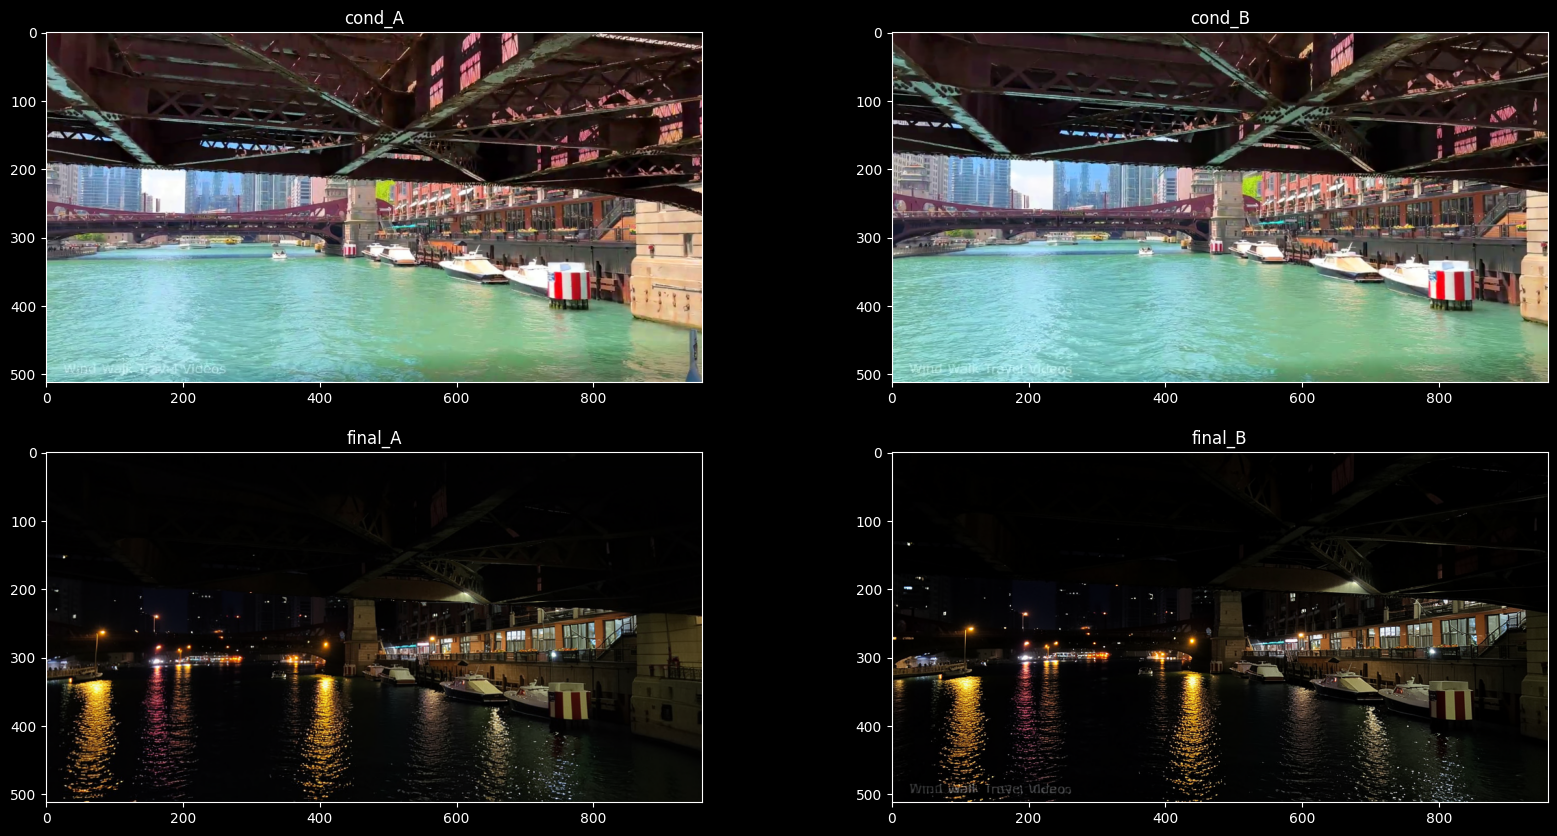

Make it midnight, add streetlights


In [153]:
def process_latent(latent):
    img = denorm_unpatchified_latents(latent, mean=vae_mean, std=vae_std)
    img = decode_latents(img, vae)
    img = denorm_image(img)
    return torch_to_np(img)


latents = [
    cond_latents_A,
    cond_latents_B,
    final_latents_A,
    final_latents_B,
]
cond_image_A, cond_image_B, final_image_A, final_image_B = map(process_latent, latents)


fig, ax = plt.subplots(2, 2, figsize=(20, 10))
ax[0, 0].imshow(cond_image_A)
ax[0, 0].set_title("cond_A")
ax[0, 1].imshow(cond_image_B)
ax[0, 1].set_title("cond_B")
ax[1, 0].imshow(final_image_A)
ax[1, 0].set_title("final_A")
ax[1, 1].imshow(final_image_B)
ax[1, 1].set_title("final_B")
plt.show()

print(prompt)

In [154]:
num_blocks = 20000

latent_height = height // 8
latent_width = width // 8


all_cond_latents_A = torch.zeros(
    (num_blocks, 32, latent_height, latent_width),
    dtype=torch.float16,
)

all_prompts = []
all_cond_latents_B = all_cond_latents_A.clone()
all_final_latents_A = all_cond_latents_A.clone()
all_final_latents_B = all_cond_latents_A.clone()

In [155]:
for i in tqdm(range(num_blocks)):
    try:
        frame_A, frame_B = get_next_frame_pair(
            cap, skip=100, distance=random.randint(1, 50)
        )
    except StopIteration:
        print("End of video reached, restarting...")
        cap.release()
        cap = cv2.VideoCapture(random_video_path())
        frame_A, frame_B = get_next_frame_pair(
            cap, skip=1000, distance=random.randint(1, 50)
        )

    (
        prompt,
        cond_latents_A,
        cond_latents_B,
        final_latents_A,
        final_latents_B,
    ) = process_pair(frame_A, frame_B)

    all_prompts.append(prompt)
    all_cond_latents_A[i] = cond_latents_A.squeeze(0).cpu()
    all_cond_latents_B[i] = cond_latents_B.squeeze(0).cpu()
    all_final_latents_A[i] = final_latents_A.squeeze(0).cpu()
    all_final_latents_B[i] = final_latents_B.squeeze(0).cpu()

 13%|█▎        | 2653/20000 [47:49<5:14:01,  1.09s/it]

End of video reached, restarting...


 17%|█▋        | 3357/20000 [1:00:31<5:01:22,  1.09s/it]

End of video reached, restarting...


 31%|███       | 6186/20000 [1:51:32<4:09:29,  1.08s/it]

...

 90%|█████████ | 18074/20000 [5:25:58<34:51,  1.09s/it]  

End of video reached, restarting...


 98%|█████████▊| 19507/20000 [5:51:49<08:52,  1.08s/it]

End of video reached, restarting...


100%|██████████| 20000/20000 [6:00:42<00:00,  1.08s/it]


In [156]:
torch.save(
    all_cond_latents_A, "../../precomputes/flow_refractor/test-7/all_cond_latents_A.pt"
)
torch.save(
    all_cond_latents_B, "../../precomputes/flow_refractor/test-7/all_cond_latents_B.pt"
)
torch.save(
    all_final_latents_A,
    "../../precomputes/flow_refractor/test-7/all_final_latents_A.pt",
)
torch.save(
    all_final_latents_B,
    "../../precomputes/flow_refractor/test-7/all_final_latents_B.pt",
)

with open("../../precomputes/flow_refractor/test-7/all_prompts.json", "w") as file:
    json.dump(all_prompts, file)